In [12]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../../results/0_data_processing/hapax_overlap.csv")
df.head()

,lang,file_a,file_b,hapaxes_a,hapaxes_b,overlap,share_a_pct,share_b_pct
0,abk,abk_wikipedia_2012_20260404141204.csv,abk_wikipedia_2021_20260404141210.csv,5843,11922,1632,27.93,13.69
1,afr,afr_mixed_2013_20260404141249.csv,afr_mixed_2014_20260404141316.csv,747526,1113789,585645,78.34,52.58
2,afr,afr_mixed_2014_20260404141316.csv,afr_mixed_2019_20260404141355.csv,1113789,1550976,829210,74.45,53.46
3,afr,afr_mixed_2013_20260404141249.csv,afr_mixed_2019_20260404141355.csv,747526,1550976,488268,65.32,31.48
4,afr,afr-za_web_2013_20260404141524.csv,afr_mixed_2014_20260404141316.csv,486046,1113789,270424,55.64,24.28


In [13]:
# For each file, find its maximum share (in its own direction) across all pairs
max_share_a = df.groupby("file_a")["share_a_pct"].max()
max_share_b = df.groupby("file_b")["share_b_pct"].max()

# Combine: for files appearing on both sides, take the overall max
all_files = set(max_share_a.index) | set(max_share_b.index)
max_shares = {}
for f in all_files:
    vals = []
    if f in max_share_a.index:
        vals.append(max_share_a[f])
    if f in max_share_b.index:
        vals.append(max_share_b[f])
    max_shares[f] = max(vals)

shares = pd.Series(max_shares, name="max_share_pct").sort_values(ascending=False)
print(f"Files: {len(shares)}")
shares.describe()

Files: 907


count    907.000000
mean      27.933010
std       22.097578
min        0.050000
25%       11.490000
50%       17.100000
75%       44.565000
max      100.000000
Name: max_share_pct, dtype: float64

In [14]:
# Load ignore list and filter out ignored files
ignored_df = pd.read_csv("../../results/0_data_processing/ignored_files.csv")
ignored_files = set(ignored_df["filename"])

# Remove pairs where either file is ignored
df_filtered = df[~df["file_a"].isin(ignored_files) & ~df["file_b"].isin(ignored_files)]

# Recompute max shares per file on filtered data
max_share_a_f = df_filtered.groupby("file_a")["share_a_pct"].max()
max_share_b_f = df_filtered.groupby("file_b")["share_b_pct"].max()

all_files_f = set(max_share_a_f.index) | set(max_share_b_f.index)
max_shares_f = {}
for f in all_files_f:
    vals = []
    if f in max_share_a_f.index:
        vals.append(max_share_a_f[f])
    if f in max_share_b_f.index:
        vals.append(max_share_b_f[f])
    max_shares_f[f] = max(vals)

shares_filtered = pd.Series(max_shares_f, name="max_share_pct").sort_values(ascending=False)
print(f"Files (after ignoring {len(ignored_files)}): {len(shares_filtered)}")
shares_filtered.describe()

Files (after ignoring 226): 576


count    576.000000
mean      11.864913
std        6.683827
min        0.050000
25%        7.032500
50%       12.055000
75%       14.917500
max       32.230000
Name: max_share_pct, dtype: float64

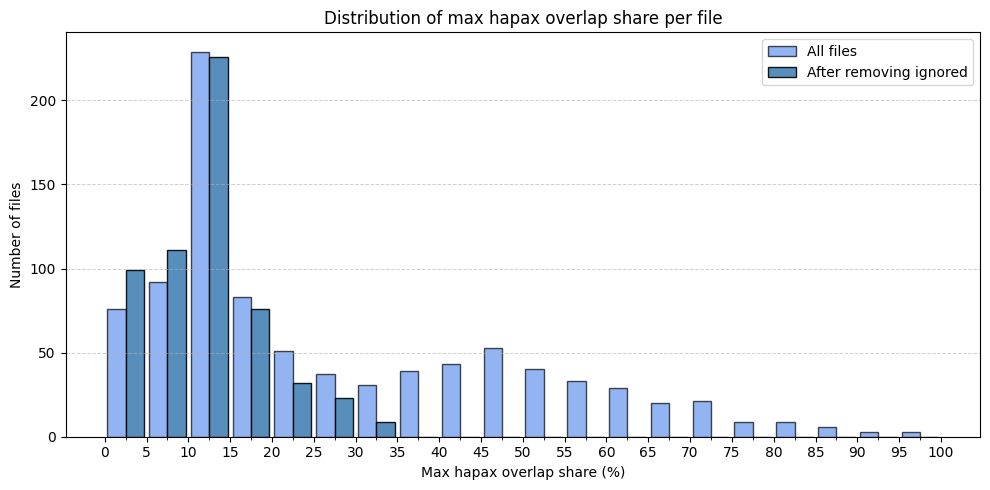

In [16]:
import numpy as np

fig, ax = plt.subplots(figsize=(10, 5))
bin_edges = np.arange(0, 105, 5)
width = 2.2  # half-bin width for side-by-side

counts_all, _ = np.histogram(shares, bins=bin_edges)
counts_filt, _ = np.histogram(shares_filtered, bins=bin_edges)
centers = (bin_edges[:-1] + bin_edges[1:]) / 2

ax.bar(centers - width / 2, counts_all, width=width, color="cornflowerblue",
       edgecolor="black", alpha=0.7, label="All files")
ax.bar(centers + width / 2, counts_filt, width=width, color="steelblue",
       edgecolor="black", alpha=0.9, label="After removing ignored")

ax.set_xlabel("Max hapax overlap share (%)")
ax.set_ylabel("Number of files")
ax.set_title("Distribution of max hapax overlap share per file")
ax.set_xticks(range(0, 105, 5))
ax.set_xticks([i * 2.5 for i in range(41)], minor=True)
ax.grid(which="major", axis="y", linestyle="--", linewidth=0.7, alpha=0.6)
ax.legend()
plt.tight_layout()
plt.show()